# Análise do Dataset Housing

 **Descrição do Projeto**

Aplicação completa do processo de **Ciência de Dados** em um conjunto de dados sobre propriedades imobiliárias. Este projeto demonstra desde a exploração inicial até a modelagem preditiva.

 **Sobre o Dataset**

O dataset Housing contém informações detalhadas sobre características de casas e seus respectivos valores de venda. É um conjunto de dados clássico utilizado para fins de análise e aprendizado em regressão.

 *Objetivos*

- **Exploração e Limpeza**: Compreender a estrutura dos dados, identificar valores ausentes e aplicar técnicas de limpeza quando necessário
- **Modelagem de Regressão**: Desenvolver modelos preditivos tanto para regressão simples (uma variável) quanto múltipla (várias variáveis)
- **Avaliação e Comparação**: Avaliar o desempenho dos modelos utilizando métricas como R², RMSE e outras, identificando o melhor modelo

---

In [1]:
#Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('Housing.csv')
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [3]:
df['price'] = df['price'].astype(float)
df['area'] = np.sqrt(df['area'].astype(float)).round(2)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   price             545 non-null    float64
 1   area              545 non-null    float64
 2   bedrooms          545 non-null    int64  
 3   bathrooms         545 non-null    int64  
 4   stories           545 non-null    int64  
 5   mainroad          545 non-null    object 
 6   guestroom         545 non-null    object 
 7   basement          545 non-null    object 
 8   hotwaterheating   545 non-null    object 
 9   airconditioning   545 non-null    object 
 10  parking           545 non-null    int64  
 11  prefarea          545 non-null    object 
 12  furnishingstatus  545 non-null    object 
dtypes: float64(2), int64(4), object(7)
memory usage: 55.5+ KB


In [5]:
#transformando variáveis categóricas em numéricas
df[['mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'prefarea']] = df[['mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'prefarea']].replace({'yes': 1, 'no': 0})
df['furnishingstatus'] =df['furnishingstatus'].replace({'furnished': 1, 'semi-furnished': 0, 'unfurnished': -1})
df.head(10)
    

/tmp/ipykernel_27274/3429454103.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[['mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'prefarea']] = df[['mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'prefarea']].replace({'yes': 1, 'no': 0})
/tmp/ipykernel_27274/3429454103.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['furnishingstatus'] =df['furnishingstatus'].replace({'furnished': 1, 'semi-furnished': 0, 'unfurnished': -1})


,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000.0,86.14,4,2,3,1,0,0,0,1,2,1,1
1,12250000.0,94.66,4,4,4,1,0,0,0,1,3,0,1
2,12250000.0,99.80,3,2,2,1,0,1,0,0,2,1,0
3,12215000.0,86.60,4,2,2,1,0,1,0,1,3,1,1
4,11410000.0,86.14,4,1,2,1,1,1,0,1,2,0,1
5,10850000.0,86.60,3,3,1,1,0,1,0,1,2,1,0
6,10150000.0,92.63,4,3,4,1,0,0,0,1,2,1,0
7,10150000.0,127.28,5,3,2,1,0,0,0,0,0,0,-1
8,9870000.0,90.00,4,1,2,1,1,1,0,1,2,1,1
9,9800000.0,75.83,3,2,4,1,1,0,0,1,1,1,-1


In [6]:
#estatisticas descritivas do dataset
df.describe().round(2)

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
count,545.00,545.00,545.00,545.00,545.00,545.00,545.00,545.00,545.00,545.00,545.00,545.00,545.00
mean,4766729.25,70.33,2.97,1.29,1.81,0.86,0.18,0.35,0.05,0.32,0.69,0.23,-0.07
std,1870439.62,14.30,0.74,0.50,0.87,0.35,0.38,0.48,0.21,0.47,0.86,0.42,0.76
min,1750000.00,40.62,1.00,1.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,-1.00
25%,3430000.00,60.00,2.00,1.00,1.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,-1.00
50%,4340000.00,67.82,3.00,1.00,2.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
75%,5740000.00,79.75,3.00,2.00,2.00,1.00,0.00,1.00,0.00,1.00,1.00,0.00,1.00
max,13300000.00,127.28,6.00,4.00,4.00,1.00,1.00,1.00,1.00,1.00,3.00,1.00,1.00


In [25]:
print(f'Preços duplicados: {df["price"].duplicated().sum()} \nAreas duplicadas: {df["area"].duplicated().sum()} ')

Preços duplicados: 319 
Areas duplicadas: 251 


## **EDA  e Data Cleaning**

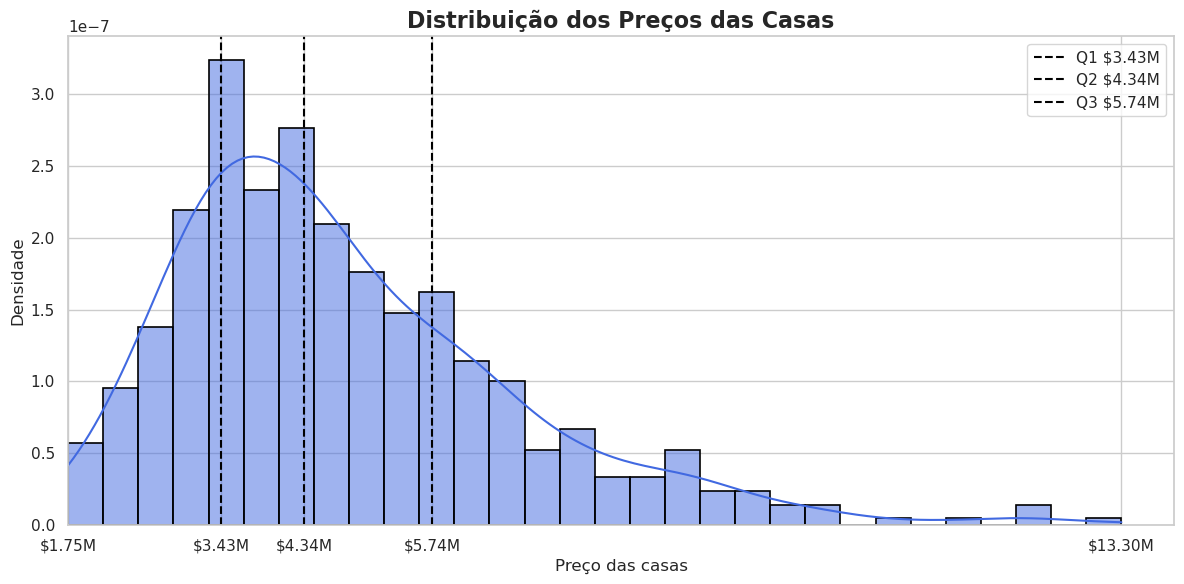

In [8]:
from matplotlib.ticker import FuncFormatter
sns.set_theme(style='whitegrid')

price_data = df['price']

q1 = price_data.quantile(0.25)
q2 = price_data.quantile(0.50)
q3 = price_data.quantile(0.75)

plt.figure(figsize=(12,6))
min_price = price_data.min()
max_price = price_data.max()

sns.histplot(price_data, bins=30, stat='density', color='royalblue', alpha=0.5, edgecolor='black', linewidth=1.2, kde=True)

plt.axvline(x=q1, color='black', linestyle='--', label=f'Q1 ${q1/1e6:.2f}M')
plt.axvline(x=q2, color='black', linestyle='--', label=f'Q2 ${q2/1e6:.2f}M')
plt.axvline(x=q3, color='black', linestyle='--', label=f'Q3 ${q3/1e6:.2f}M')
plt.gca().xaxis.set_major_formatter(
    FuncFormatter(lambda x, pos: f'${x/1e6:.2f}M')
)
plt.title('Distribuição dos Preços das Casas', fontsize=16, fontweight='bold')
plt.xlabel('Preço das casas', fontsize=12)
plt.ylabel('Densidade', fontsize=12)
plt.xlim(left=min_price)
plt.xticks([min_price, q1, q2, q3, max_price])

plt.legend()
plt.tight_layout()
plt.show()

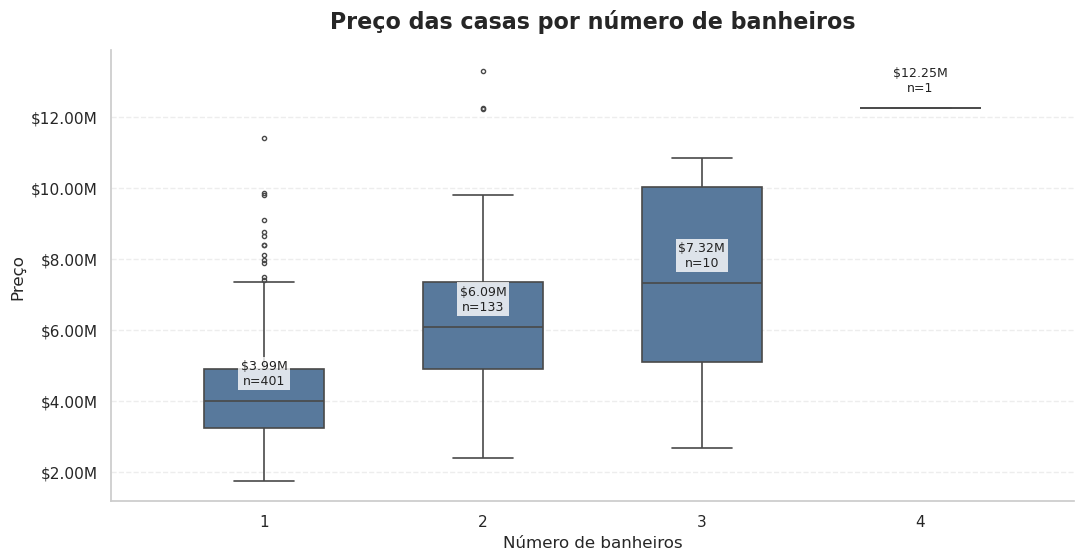

In [9]:
from matplotlib.ticker import FuncFormatter

df['bathrooms'] = pd.to_numeric(df['bathrooms'], errors='coerce')

sns.set_theme(style='whitegrid')

fig, ax = plt.subplots(figsize=(11, 6))

bathroom_levels = sorted(df['bathrooms'].dropna().unique())

sns.boxplot(
    data=df,
    x='bathrooms',
    y='price',
    order=bathroom_levels,
    color='#4C78A8',
    width=0.55,
    fliersize=3,
    linewidth=1.2,
    ax=ax
)

ax.yaxis.set_major_formatter(
    FuncFormatter(lambda value, pos: f'${value / 1e6:.2f}M')
)

ax.set_title(
    'Preço das casas por número de banheiros',
    fontsize=16,
    fontweight='bold',
    pad=16
)

ax.set_xlabel('Número de banheiros', fontsize=12)
ax.set_ylabel('Preço', fontsize=12)

ax.set_xticks(range(len(bathroom_levels)))
ax.set_xticklabels(bathroom_levels)

ax.grid(axis='y', linestyle='--', alpha=0.35)
ax.grid(axis='x', visible=False)

for position, bathroom_count in enumerate(bathroom_levels):
    bathroom_prices = df.loc[
        df['bathrooms'] == bathroom_count, 'price'
    ].dropna()

    median_price = bathroom_prices.median()
    sample_count = len(bathroom_prices)

    ax.annotate(
        f'${median_price / 1e6:.2f}M\nn={sample_count}',
        xy=(position, median_price),
        xytext=(0, 10),
        textcoords='offset points',
        ha='center',
        va='bottom',
        fontsize=9,
        color='#222222',
        bbox={
            'facecolor': 'white',
            'edgecolor': 'none',
            'alpha': 0.8,
            'pad': 2
        }
    )

ax.margins(x=0.12)

sns.despine(ax=ax)

fig.tight_layout()
plt.subplots_adjust(bottom=0.15)

plt.show()

In [10]:
df_bath1 = df[df['bathrooms'] == 1]
    
q1 = df_bath1['price'].quantile(0.25)
q3 = df_bath1['price'].quantile(0.75)
IQR = q3 - q1
lower_bound = q1 - 1.5 * IQR
upper_bound = q3 + 1.5 * IQR

outliersWith1Bathroom = df[['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad', 'airconditioning', 'parking']].query(f'bathrooms == 1 and (price < {lower_bound} or price > {upper_bound})').sort_values(by='price', ascending=False);
print(f'{outliersWith1Bathroom} Outliers com 1 banheiro: {outliersWith1Bathroom.shape[0]}')

         price    area  bedrooms  bathrooms  stories  mainroad  \
4   11410000.0   86.14         4          1        2         1   
8    9870000.0   90.00         4          1        2         1   
10   9800000.0  114.89         3          1        2         1   
15   9100000.0   77.46         4          1        2         1   
20   8750000.0   65.73         3          1        2         1   
22   8645000.0   89.72         3          1        1         1   
27   8400000.0   94.21         3          1        1         1   
31   8400000.0   83.67         3          1        4         1   
34   8120000.0   82.70         5          1        2         1   
38   7962500.0   77.46         3          1        4         1   
40   7875000.0   80.93         3          1        2         1   
47   7490000.0   81.24         3          1        4         1   
51   7420000.0   79.53         3          1        4         1   

    airconditioning  parking  
4                 1        2  
8            

In [11]:
df = df.drop(outliersWith1Bathroom.index)

In [12]:
df_bath2 = df[df['bathrooms'] == 2]

q1 = df_bath2['price'].quantile(0.25)
q3 = df_bath2['price'].quantile(0.75)
IQR = q3 - q1
lower_bound = q1 - 1.5 * IQR
upper_bound = q3 + 1.5 * IQR

outliersWith2Bathrooms = df[['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad', 'airconditioning', 'parking']].query(f'bathrooms == 2 and (price < {lower_bound} or price > {upper_bound})').sort_values(by='price', ascending=False);
print(outliersWith2Bathrooms)

        price   area  bedrooms  bathrooms  stories  mainroad  airconditioning  \
0  13300000.0  86.14         4          2        3         1                1   
2  12250000.0  99.80         3          2        2         1                0   
3  12215000.0  86.60         4          2        2         1                1   

   parking  
0        2  
2        2  
3        3  


In [13]:
df = df.drop(outliersWith2Bathrooms.index) 

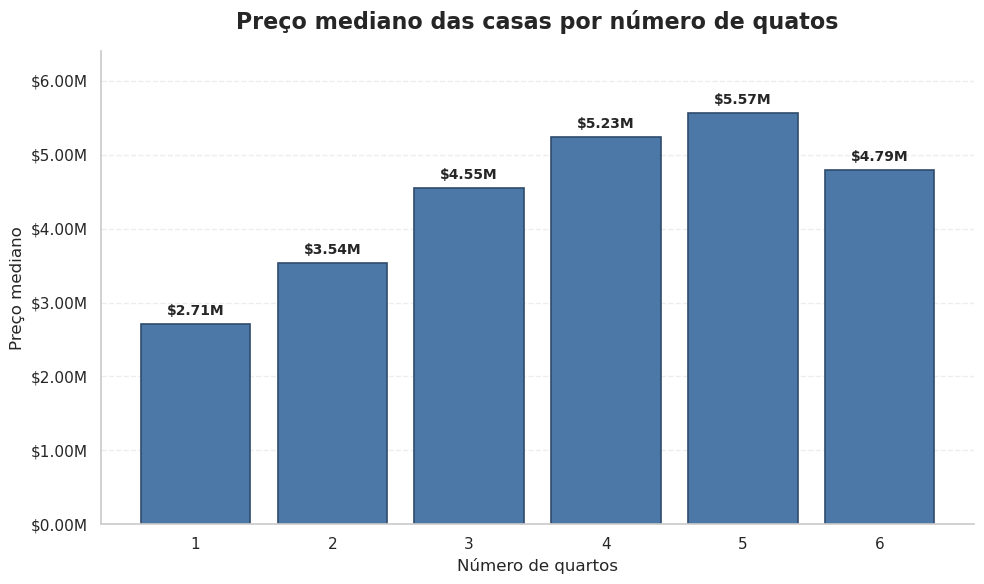

In [14]:
from matplotlib.ticker import FuncFormatter

median_prices = (
    df.groupby('bedrooms', as_index=False)['price']
      .median()
      .sort_values('bedrooms')
)

fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.bar(
    median_prices['bedrooms'].astype(str),
    median_prices['price'],
    color='#4C78A8',
    edgecolor='#2F4B6C',
    linewidth=1.2
)

ax.yaxis.set_major_formatter(FuncFormatter(lambda value, pos: f'${value / 1e6:.2f}M'))
ax.set_title('Preço mediano das casas por número de quatos', fontsize=16, fontweight='bold', pad=16)
ax.set_xlabel('Número de quartos', fontsize=12)
ax.set_ylabel('Preço mediano', fontsize=12)
ax.grid(axis='y', linestyle='--', alpha=0.35)
ax.grid(axis='x', visible=False)

for bar, price in zip(bars, median_prices['price']):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + median_prices['price'].max() * 0.015,
        f'${price / 1e6:.2f}M',
        ha='center',
        va='bottom',
        fontsize=10,
        fontweight='bold'
    )

ax.set_ylim(0, median_prices['price'].max() * 1.15)
sns.despine(ax=ax)
fig.tight_layout()
plt.show()

Text(0, 0.5, 'Preco')

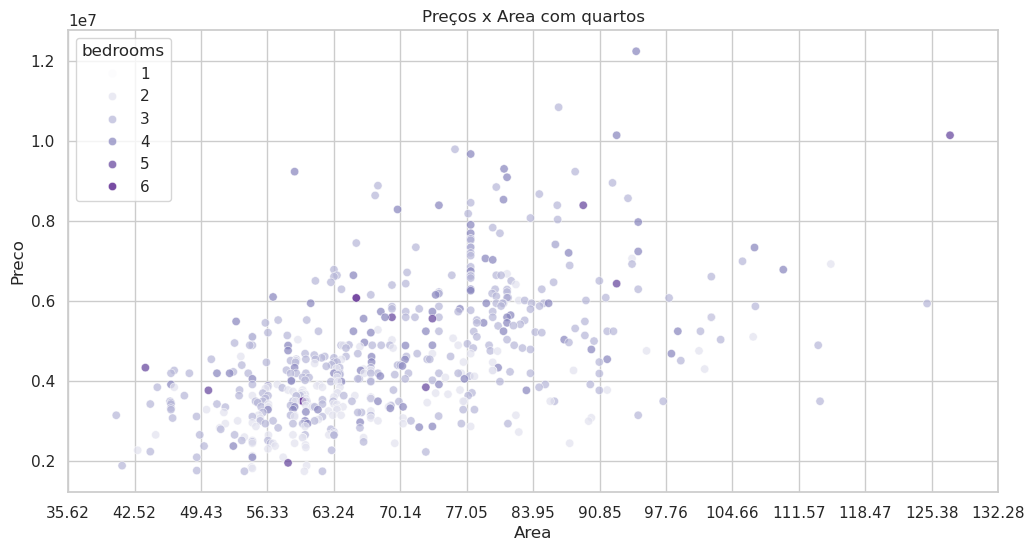

In [15]:
sns.set_theme(style='whitegrid')
plt.figure(figsize=(12,6)) 
sns.scatterplot(data=df, x='area', y='price', hue='bedrooms', palette='Purples', alpha=0.7);
plt.xticks(np.linspace(df['area'].min() - 5, df['area'].max() + 5, 15))
plt.title('Preços x Area com quartos')
plt.xlabel('Area')
plt.ylabel('Preco')


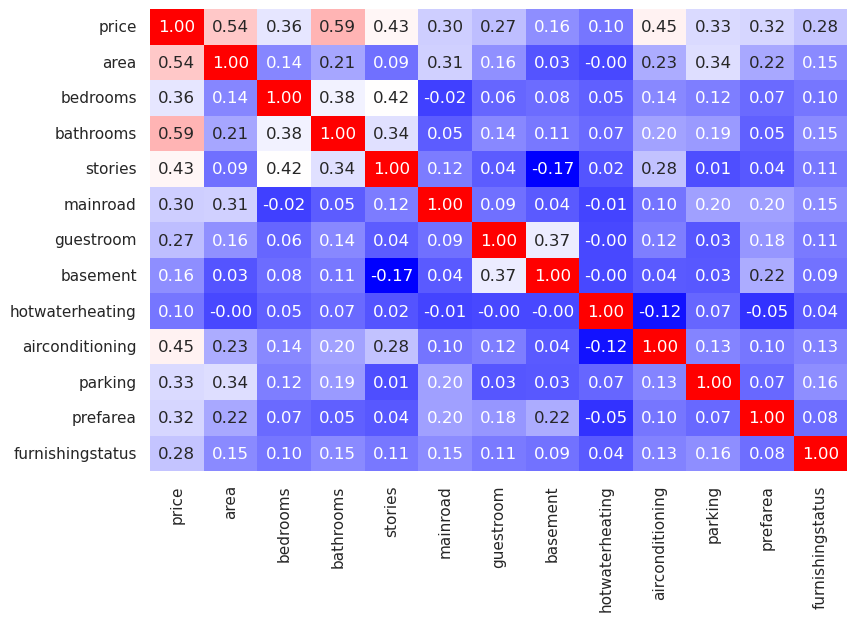

In [24]:
#Geração do heatmap para indetificar as variveis com maior correlação

fig, ax = plt.subplots(figsize=(9, 6))
sns.heatmap(df.corr(), fmt='.2f', cmap='bwr', cbar=False, annot=True);

## **Machine Learning**

In [40]:
#Treinando os modelos

from sklearn.linear_model import LinearRegression, Ridge, Lasso;
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [41]:
features = df.drop('price', axis=1)
labels = np.log1p(df['price']);
X_train, X_test, Y_train, Y_test = train_test_split(features, labels, test_size=0.2, random_state=42);


LinearRegressor = LinearRegression();
LinearRegressor.fit(X_train, Y_train);
y_pred_log = LinearRegressor.predict(X_test)
y_pred_actual = np.expm1(y_pred_log) 
y_test_actual = np.expm1(Y_test);
print(f'R² no Teste: {r2_score(y_test_actual, y_pred_actual):.4f}')
print(f'MAE no Teste: ${mean_absolute_error(y_test_actual, y_pred_actual):,.2f}')


R² no Teste: 0.7413
MAE no Teste: $765,410.37
